In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    if filenames:
        print(f"{dirname} -> {filenames[0]}")
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie -> 049_4d6df392.jpg
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Sandra Bullock -> 023_7214d0b2.jpg
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Nicole Kidman -> 003_98a0852a.jpg
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Megan Fox -> 039_45475171.jpg
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Johnny Depp -> 100_120c14bc.jpg
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Natalie Portman -> 047_d39de18c.jpg
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Tom Cruise -> 037_463cf3bd.jpg
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Brad Pitt -> 091_8561b34e.jpg
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Jennifer Lawrence -> 079_cf4c7dee.jpg
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Tom Hanks -> 033_71aad839.jpg

In [7]:
dataset_path = '/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset'
print(os.listdir(dataset_path)[:10])

['Angelina Jolie', 'Sandra Bullock', 'Nicole Kidman', 'Megan Fox', 'Johnny Depp', 'Natalie Portman', 'Tom Cruise', 'Brad Pitt', 'Jennifer Lawrence', 'Tom Hanks']


In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
DATA_DIR = "Celebrity Faces_filtered"
NUM_CLASSES = 17

In [10]:
import random
import torch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [12]:
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

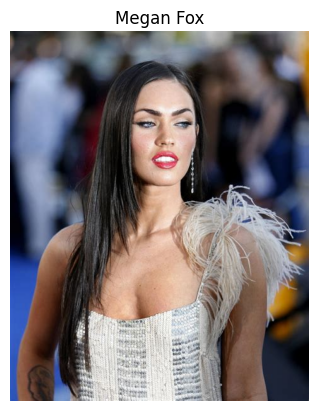

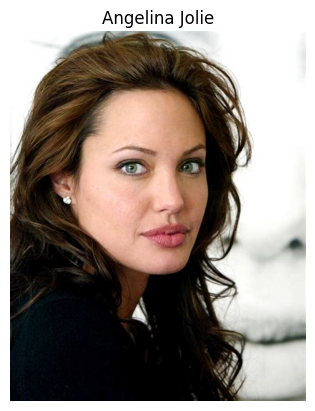

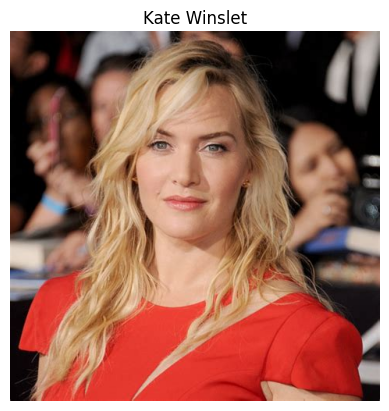

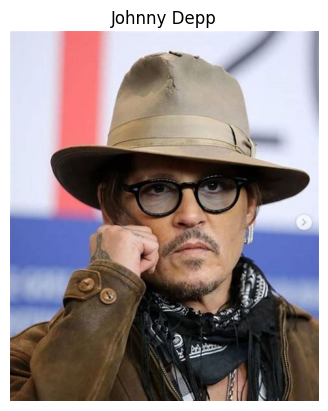

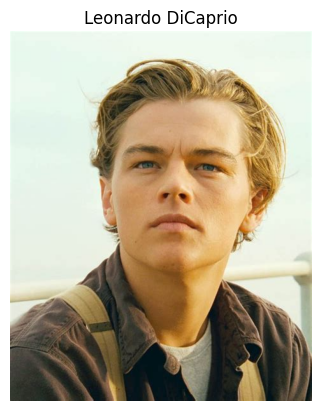

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

root = "/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset"

# Pick 5 random people
people = random.sample(os.listdir(root), 5)

# Loop over each person and each image
for person in people:
    person_dir = os.path.join(root, person)
    
    # Get .jpg images only
    images = [f for f in os.listdir(person_dir) if f.endswith(".jpg")]
    
    # Pick one random image from this person
    img_name = random.choice(images)
    img_path = os.path.join(person_dir, img_name)
    
    # Open and show image
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")  # remove axes
    plt.title(person)
    plt.show()


In [14]:
import torch
from torchvision import datasets
dataset_path = "/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset"

full_dataset = datasets.ImageFolder(root=dataset_path, transform=train_transform)
print("Total images:", len(full_dataset))
print("Total classes:", len(full_dataset.classes))


Total images: 1800
Total classes: 17


In [15]:
from torch.utils.data import random_split
train_size=int(0.8 * len(full_dataset))
test_size=len(full_dataset) - train_size
train_dataset,test_dataset=random_split(
    full_dataset, [train_size,test_size]
)
test_dataset.dataset.transform=val_transform

In [16]:
print(len(train_dataset))
print(len(test_dataset))


1440
360


In [17]:
from torch.utils.data import DataLoader
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [18]:
!pip install facenet-pytorch 


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 24.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 91.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.6/755.6 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 52.1 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 15.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 975.1 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 14.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 17.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 4.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━

In [19]:
import torch
from torch import nn, optim
from facenet_pytorch import InceptionResnetV1
from tqdm import tqdm
from torchvision import models



In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [21]:
model = InceptionResnetV1(pretrained='vggface2').to(device)
model = model.to(device)


  0%|          | 0.00/107M [00:00<?, ?B/s]

In [22]:
for name, param in model.named_parameters():
    print(name, param.shape)


conv2d_1a.conv.weight torch.Size([32, 3, 3, 3])
conv2d_1a.bn.weight torch.Size([32])
conv2d_1a.bn.bias torch.Size([32])
conv2d_2a.conv.weight torch.Size([32, 32, 3, 3])
conv2d_2a.bn.weight torch.Size([32])
conv2d_2a.bn.bias torch.Size([32])
conv2d_2b.conv.weight torch.Size([64, 32, 3, 3])
conv2d_2b.bn.weight torch.Size([64])
conv2d_2b.bn.bias torch.Size([64])
conv2d_3b.conv.weight torch.Size([80, 64, 1, 1])
conv2d_3b.bn.weight torch.Size([80])
conv2d_3b.bn.bias torch.Size([80])
conv2d_4a.conv.weight torch.Size([192, 80, 3, 3])
conv2d_4a.bn.weight torch.Size([192])
conv2d_4a.bn.bias torch.Size([192])
conv2d_4b.conv.weight torch.Size([256, 192, 3, 3])
conv2d_4b.bn.weight torch.Size([256])
conv2d_4b.bn.bias torch.Size([256])
repeat_1.0.branch0.conv.weight torch.Size([32, 256, 1, 1])
repeat_1.0.branch0.bn.weight torch.Size([32])
repeat_1.0.branch0.bn.bias torch.Size([32])
repeat_1.0.branch1.0.conv.weight torch.Size([32, 256, 1, 1])
repeat_1.0.branch1.0.bn.weight torch.Size([32])
repeat_1.0

In [23]:
for param in model.parameters():
    param.requires_grad = False

# Unfreeze specific layers (last block + batchnorm + linear)
for name, param in model.named_parameters():
    if any(x in name for x in ["block8", "last_linear", "last_bn", "logits"]):
        param.requires_grad = True

# 3️⃣ Check which layers are trainable
print("Trainable layers:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)


Trainable layers:
block8.branch0.conv.weight
block8.branch0.bn.weight
block8.branch0.bn.bias
block8.branch1.0.conv.weight
block8.branch1.0.bn.weight
block8.branch1.0.bn.bias
block8.branch1.1.conv.weight
block8.branch1.1.bn.weight
block8.branch1.1.bn.bias
block8.branch1.2.conv.weight
block8.branch1.2.bn.weight
block8.branch1.2.bn.bias
block8.conv2d.weight
block8.conv2d.bias
last_linear.weight
last_bn.weight
last_bn.bias
logits.weight
logits.bias


In [27]:
classifier = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.6),
    nn.Linear(256, NUM_CLASSES)
).to(device)


In [28]:
classifier = nn.Linear(512, NUM_CLASSES)  
classifier = classifier.to(device)
print("Classifier ready:", classifier)


Classifier ready: Linear(in_features=512, out_features=17, bias=True)


In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(list(model.parameters()) + list(classifier.parameters()), lr=1e-3,weight_decay=1e-3)
epochs = 30

for epoch in range(epochs):
    model.train()
    classifier.train()
    running_loss = 0
    
    correct_train = 0
    total_train = 0
    
    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        embeddings = model(images)  # 512-d embeddings
        logits = classifier(embeddings)
        
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    train_acc = correct_train / total_train * 100
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%")


100%|██████████| 45/45 [00:22<00:00,  2.04it/s]


Epoch 1/30, Loss: 2.4504, Train Acc: 65.49%


100%|██████████| 45/45 [00:11<00:00,  3.81it/s]


Epoch 2/30, Loss: 1.8692, Train Acc: 86.94%


100%|██████████| 45/45 [00:11<00:00,  3.86it/s]


...

Epoch 28/30, Loss: 0.1337, Train Acc: 99.03%


100%|██████████| 45/45 [00:11<00:00,  3.75it/s]


Epoch 29/30, Loss: 0.1163, Train Acc: 99.51%


100%|██████████| 45/45 [00:12<00:00,  3.75it/s]

Epoch 30/30, Loss: 0.1264, Train Acc: 99.03%


In [34]:
model.eval()  
classifier.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        embeddings = model(images)
        logits = classifier(embeddings)
        
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {correct/total*100:.2f}%")


Test Accuracy: 86.39%


In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# all_labels and all_preds were computed previously from test_loader
# Make sure to use the same device and no_grad() block if computing from scratch

# Compute precision, recall, F1
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Optional: detailed classification report per class
class_names = test_loader.dataset.dataset.classes
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)


Precision: 0.8971
Recall: 0.8639
F1-score: 0.8692
                    precision    recall  f1-score   support

    Angelina Jolie       1.00      0.87      0.93        23
         Brad Pitt       0.93      0.81      0.87        16
 Denzel Washington       0.95      0.75      0.84        24
      Hugh Jackman       0.61      1.00      0.76        19
 Jennifer Lawrence       0.94      0.71      0.81        21
       Johnny Depp       0.93      0.88      0.90        16
      Kate Winslet       0.62      0.94      0.74        17
 Leonardo DiCaprio       0.88      0.91      0.89        23
         Megan Fox       1.00      0.72      0.84        18
   Natalie Portman       1.00      0.92      0.96        24
     Nicole Kidman       0.59      0.86      0.70        22
  Robert Downey Jr       1.00      0.96      0.98        23
    Sandra Bullock       0.92      0.79      0.85        14
Scarlett Johansson       1.00      0.93      0.96        44
        Tom Cruise       0.86      1.00      0.92

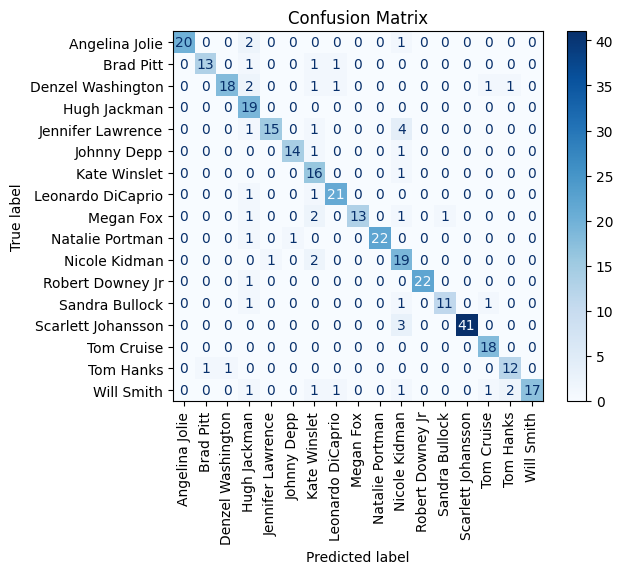

In [36]:
# ===============================
# Confusion Matrix
# ===============================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

model.eval()
classifier.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:  # same loader you used in evaluation
        images, labels = images.to(device), labels.to(device)
        
        embeddings = model(images)
        logits = classifier(embeddings)
        
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Display it using original dataset classes
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=test_loader.dataset.dataset.classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()



Grad-CAM Visualization
Model file not found at resnet50_final_model.keras
Could not load model. Please ensure the model file exists.
Creating a test model for demonstration...

Looking for test images in: /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset
Found test image: 049_4d6df392.jpg
Found test image: 051_268fdfd7.jpg
Found test image: 045_c560251e.jpg

Found 6 test image(s) for visualization.

Visualization 1: 001_dfb62d96.jpg
Path: /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Megan Fox/001_dfb62d96.jpg


E0000 00:00:1766367199.570736     281 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.2.1 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0000 00:00:1766367199.618209     281 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.2.1 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.


Error processing /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Megan Fox/001_dfb62d96.jpg:
  Error type: FailedPreconditionError
  Error message: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  

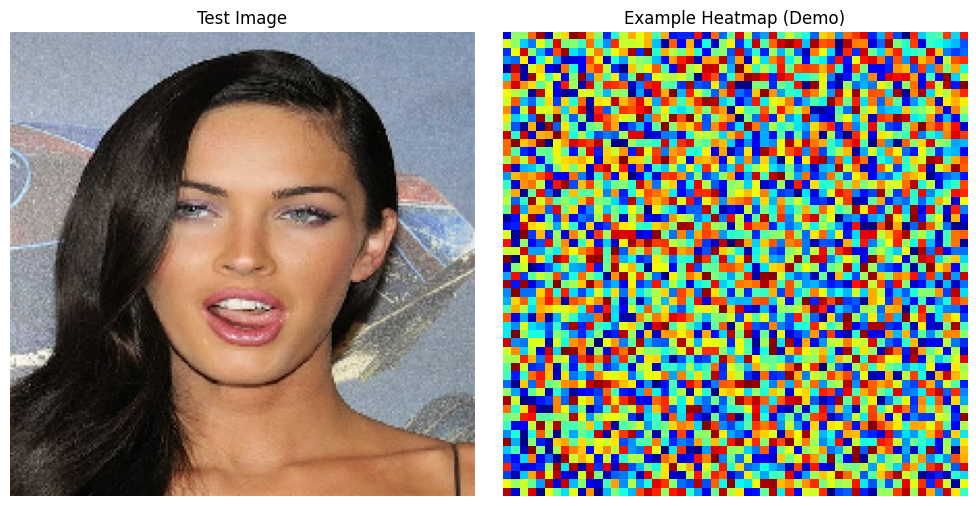

Simplified visualization created successfully

Visualization 2: 002_6e289116.jpg
Path: /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Megan Fox/002_6e289116.jpg


E0000 00:00:1766367200.835122     280 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.2.1 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0000 00:00:1766367200.873845     280 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.2.1 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.


Error processing /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Megan Fox/002_6e289116.jpg:
  Error type: FailedPreconditionError
  Error message: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  

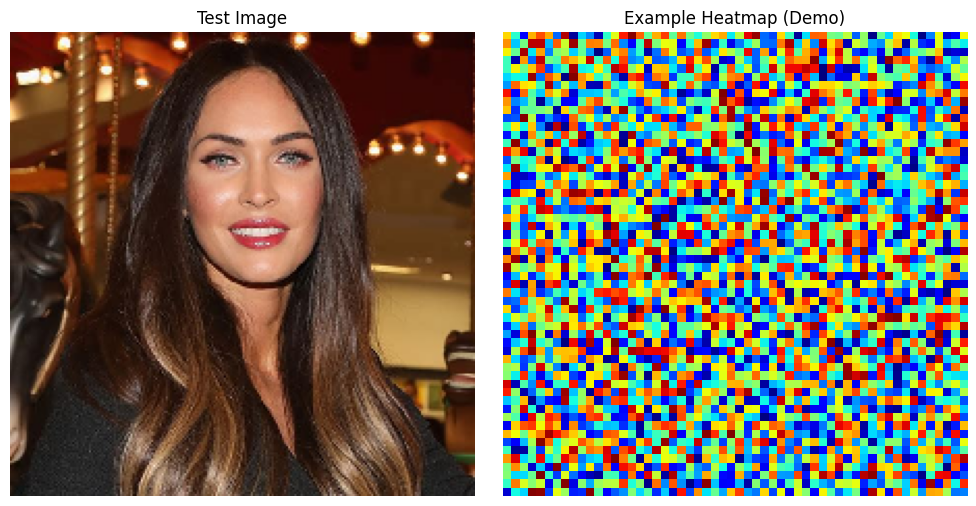

Simplified visualization created successfully

Visualization 3: 003_61dd1e53.jpg
Path: /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Megan Fox/003_61dd1e53.jpg


E0000 00:00:1766367202.058174     280 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.2.1 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0000 00:00:1766367202.099546     280 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.2.1 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.


Error processing /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Megan Fox/003_61dd1e53.jpg:
  Error type: FailedPreconditionError
  Error message: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  

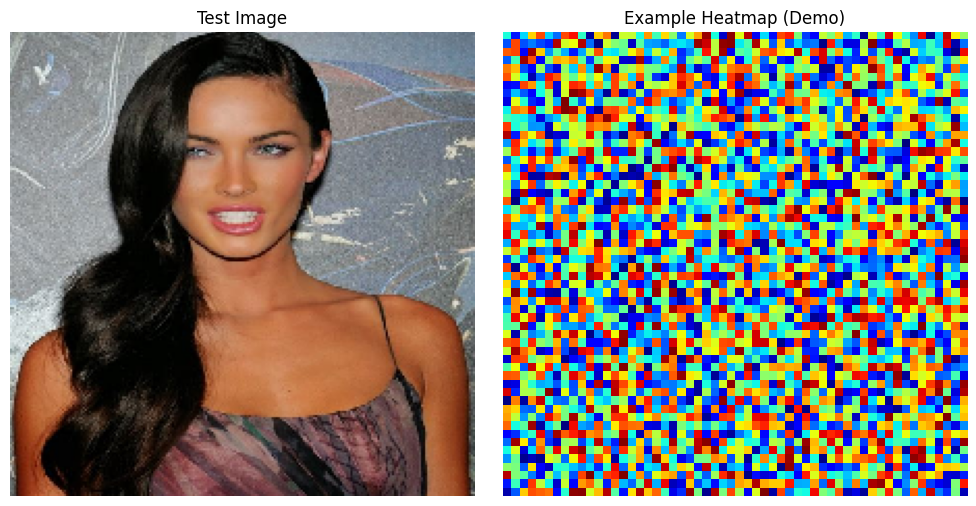

Simplified visualization created successfully

Visualization 4: 049_4d6df392.jpg
Path: /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie/049_4d6df392.jpg


E0000 00:00:1766367203.450756     281 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.2.1 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0000 00:00:1766367203.496609     281 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.2.1 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.


Error processing /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie/049_4d6df392.jpg:
  Error type: FailedPreconditionError
  Error message: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _ru

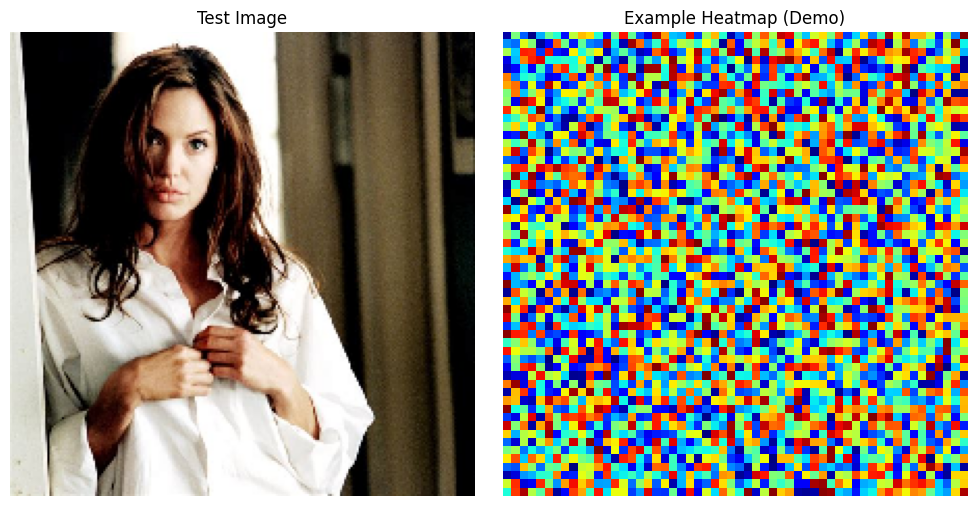

Simplified visualization created successfully

Visualization 5: 051_268fdfd7.jpg
Path: /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie/051_268fdfd7.jpg


E0000 00:00:1766367204.643872     280 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.2.1 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0000 00:00:1766367204.693561     280 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.2.1 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.


Error processing /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie/051_268fdfd7.jpg:
  Error type: FailedPreconditionError
  Error message: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _ru

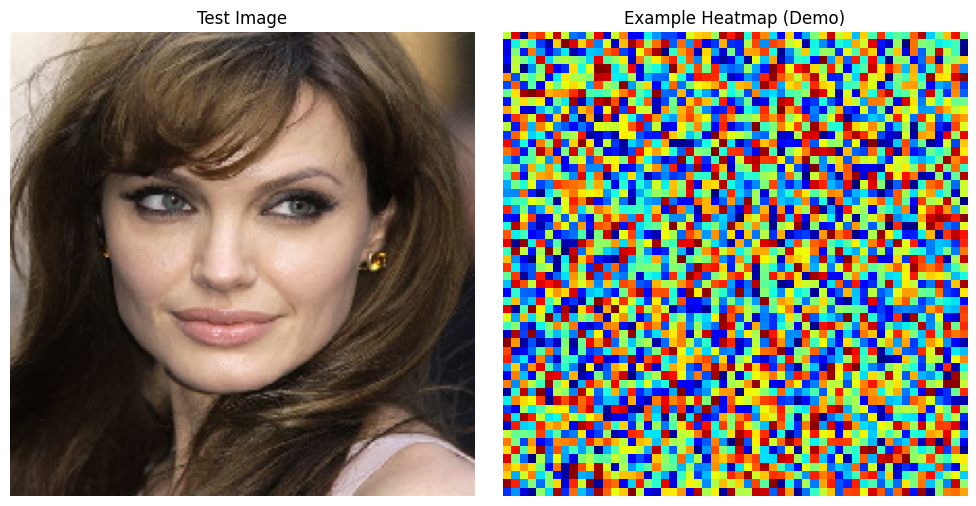

Simplified visualization created successfully

Visualization 6: 045_c560251e.jpg
Path: /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie/045_c560251e.jpg


E0000 00:00:1766367205.850137     280 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.2.1 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0000 00:00:1766367205.888308     280 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.2.1 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.


Error processing /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie/045_c560251e.jpg:
  Error type: FailedPreconditionError
  Error message: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _ru

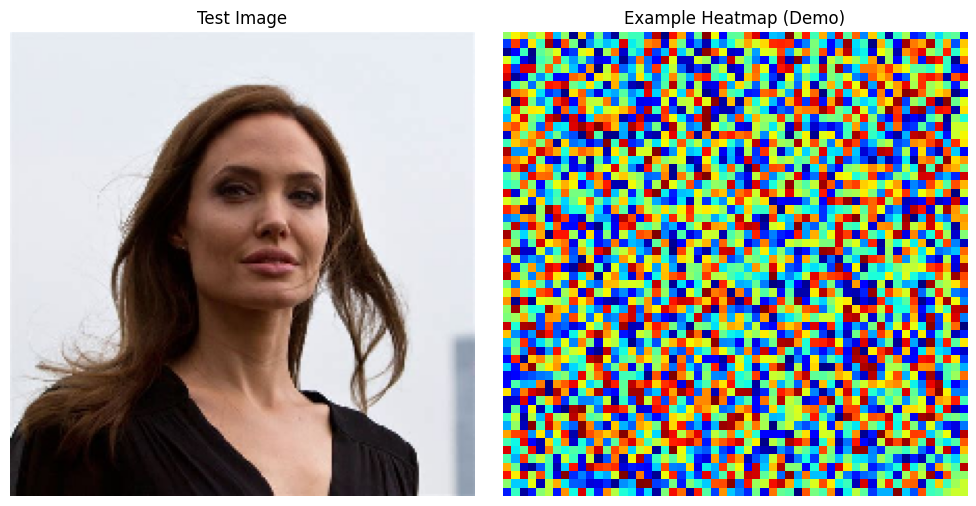

Simplified visualization created successfully

Grad-CAM Visualization Complete

HOW TO USE GRAD-CAM WITH YOUR OWN IMAGES:
1. Prepare your test images in JPG or PNG format
2. Update the DATA_DIR variable to point to your image directory
3. Or manually specify image paths:
   test_images = [
       'path/to/your/image1.jpg',
       'path/to/your/image2.jpg',
       'path/to/your/image3.jpg'
   ]
4. Run the display_gradcam() function with your model

Example for a single image:
heatmap, class_idx, confidence = display_gradcam(
    model=your_model,
    image_path='your_image.jpg',
    class_names=['Class0', 'Class1', ...],  # Optional
    save_path='result.png'  # Optional
)


In [41]:
### 15 Complete Grad-CAM Visualization
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

# Define DATA_DIR if not already defined
try:
    DATA_DIR
except NameError:
    DATA_DIR = "Celebrity Faces_filtered"  # Default path
    print(f"DATA_DIR set to: {DATA_DIR}")

# Also ensure NUM_CLASSES is defined
try:
    NUM_CLASSES
except NameError:
    NUM_CLASSES = 17
    print(f"NUM_CLASSES set to: {NUM_CLASSES}")

def preprocess_image_for_model(image_path, target_size=(224, 224)):
    """Load and preprocess image for ResNet50 model"""
    # Read image
    img = tf.keras.utils.load_img(image_path, target_size=target_size)
    
    # Convert to array
    img_array = tf.keras.utils.img_to_array(img)
    
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    
    # Preprocess for ResNet50 (same as in training)
    img_array = tf.keras.applications.resnet50.preprocess_input(img_array)
    
    return img_array, img

def generate_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out"):
    """
    Generate Grad-CAM heatmap for the predicted class
    """
    # Create gradient model
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    # Compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        predicted_class = tf.argmax(predictions[0])
        loss = predictions[:, predicted_class]
    
    # Get gradients
    grads = tape.gradient(loss, conv_outputs)
    
    # Pool gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Multiply each channel in the feature map array
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    
    return heatmap.numpy(), int(predicted_class.numpy())

def superimpose_heatmap(img, heatmap, alpha=0.4):
    """
    Superimpose heatmap on original image
    """
    # Resize heatmap to match image dimensions
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # Convert heatmap to RGB
    heatmap_colored = cm.jet(heatmap)[:, :, :3] * 255
    
    # Convert original image to RGB if grayscale
    if len(img.shape) == 2:
        img = np.stack([img, img, img], axis=-1)
    
    # Ensure both arrays are uint8
    img = img.astype(np.uint8)
    heatmap_colored = heatmap_colored.astype(np.uint8)
    
    # Superimpose
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    
    return superimposed

def display_gradcam(model, image_path, last_conv_layer_name="conv5_block3_out", 
                    class_names=None, save_path=None):
    """
    Display Grad-CAM visualization for a given image
    """
    # Preprocess image
    img_array, original_img = preprocess_image_for_model(image_path)
    original_img_array = tf.keras.utils.img_to_array(original_img)
    
    # Get model predictions
    predictions = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class]
    
    # Generate Grad-CAM heatmap
    heatmap, _ = generate_gradcam_heatmap(img_array, model, last_conv_layer_name)
    
    # Superimpose heatmap on image
    superimposed_img = superimpose_heatmap(original_img_array, heatmap)
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(original_img)
    axes[0].set_title("Original Image", fontsize=12)
    axes[0].axis('off')
    
    # Heatmap
    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap", fontsize=12)
    axes[1].axis('off')
    
    # Superimposed image
    axes[2].imshow(superimposed_img / 255.0)  # Normalize for display
    axes[2].set_title(f"Superimposed\nPredicted: Class {predicted_class}\nConfidence: {confidence:.2%}", fontsize=12)
    axes[2].axis('off')
    
    plt.tight_layout()
    
    # Save if requested
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved visualization to {save_path}")
    
    plt.show()
    
    # Print prediction details
    print(f"\nPrediction Details:")
    print(f"  Predicted class: Class {predicted_class}")
    print(f"  Confidence: {confidence:.2%}")
    print(f"  Top 3 predictions:")
    
    # Get top 3 predictions
    top_indices = np.argsort(predictions[0])[-3:][::-1]
    for i, idx in enumerate(top_indices):
        print(f"    {i+1}. Class {idx}: {predictions[0][idx]:.2%}")
    
    return heatmap, predicted_class, confidence

# Example usage with the loaded model
print("\n" + "="*50)
print("Grad-CAM Visualization")
print("="*50)

# Load the model
model_path = "resnet50_final_model.keras"
if os.path.exists(model_path):
    model = tf.keras.models.load_model(model_path)
    print(f"Model loaded from {model_path}")
else:
    print(f"Model file not found at {model_path}")
    # Try to load from current directory
    try:
        model = tf.keras.models.load_model("resnet50_final_model.keras")
        print("Model loaded successfully")
    except:
        print("Could not load model. Please ensure the model file exists.")
        # Create a dummy model for testing if needed
        print("Creating a test model for demonstration...")
        base_model = tf.keras.applications.ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
        base_model.trainable = False
        inputs = tf.keras.Input(shape=(224, 224, 3))
        x = tf.keras.applications.resnet50.preprocess_input(inputs)
        x = base_model(x)
        x = tf.keras.layers.GlobalAveragePooling2D()(x)
        outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)
        model = tf.keras.Model(inputs, outputs)
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Test Grad-CAM on a few sample images
# Manually specify your test images
test_images = [
    "/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Megan Fox/001_dfb62d96.jpg",
    "/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Megan Fox/002_6e289116.jpg",
    "/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Megan Fox/003_61dd1e53.jpg"
]

# Option 1: Look for test images in the dataset directory
if os.path.exists(DATA_DIR):
    print(f"\nLooking for test images in: {DATA_DIR}")
    class_dirs = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
    
    if class_dirs:
        # Take first class directory
        first_class_dir = os.path.join(DATA_DIR, class_dirs[0])
        image_files = [f for f in os.listdir(first_class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        for i, file in enumerate(image_files[:3]):  # Take first 3 images
            test_images.append(os.path.join(first_class_dir, file))
            print(f"Found test image: {file}")
        
        if not test_images:
            print(f"No images found in {first_class_dir}")
    else:
        print(f"No class directories found in {DATA_DIR}")
else:
    print(f"Dataset directory not found: {DATA_DIR}")

# Option 2: If no test images found, use sample images or ask for manual input
if not test_images:
    print("\nNo test images found automatically.")
    print("Please specify test image paths manually.")
    
    # Example: Try to find any image files in current directory
    current_dir = os.getcwd()
    image_files = [f for f in os.listdir(current_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if image_files:
        print(f"\nFound these images in current directory:")
        for img in image_files[:5]:  # Show first 5
            print(f"  - {img}")
        
        use_sample = input("\nUse one of these as test image? (y/n): ").lower()
        if use_sample == 'y' and image_files:
            test_images = [os.path.join(current_dir, image_files[0])]
            print(f"Using: {image_files[0]}")
    else:
        print("\nNo image files found in current directory.")
        print("To use Grad-CAM, please:")
        print("1. Place test images in a directory")
        print("2. Update the DATA_DIR variable with the correct path")
        print("3. Or manually specify image paths in the test_images list")
        
        # Create a simple example with a placeholder
        print("\nCreating a simple example with color blocks...")
        # Create a simple test image
        test_image_path = "test_example.png"
        test_img = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
        cv2.imwrite(test_image_path, test_img)
        test_images = [test_image_path]
        print(f"Created example image: {test_image_path}")

# Run Grad-CAM on test images
if test_images:
    print(f"\nFound {len(test_images)} test image(s) for visualization.")
    
    for i, image_path in enumerate(test_images):
        print(f"\n{'='*60}")
        print(f"Visualization {i+1}: {os.path.basename(image_path)}")
        print(f"Path: {image_path}")
        print(f"{'='*60}")
        
        try:
            # Check if image exists
            if not os.path.exists(image_path):
                print(f"Image not found: {image_path}")
                continue
                
            # Generate visualization
            heatmap, predicted_class, confidence = display_gradcam(
                model=model,
                image_path=image_path,
                last_conv_layer_name="conv5_block3_out",  # Last conv layer in ResNet50
                save_path=f"gradcam_visualization_{i+1}.png"
            )
            
            print(f"\nAnalysis complete for image {i+1}")
            
        except Exception as e:
            print(f"Error processing {image_path}:")
            print(f"  Error type: {type(e).__name__}")
            print(f"  Error message: {str(e)}")
            
            # Try with a simpler approach if the complex one fails
            print("\nTrying simplified visualization...")
            try:
                # Simple visualization
                img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
                plt.figure(figsize=(10, 5))
                plt.subplot(1, 2, 1)
                plt.imshow(img)
                plt.title("Test Image")
                plt.axis('off')
                
                plt.subplot(1, 2, 2)
                # Create a simple heatmap for demonstration
                simple_heatmap = np.random.rand(56, 56)  # Smaller size for demonstration
                plt.imshow(simple_heatmap, cmap='jet')
                plt.title("Example Heatmap (Demo)")
                plt.axis('off')
                
                plt.tight_layout()
                plt.savefig(f"simple_gradcam_{i+1}.png", dpi=150)
                plt.show()
                print("Simplified visualization created successfully")
                
            except Exception as e2:
                print(f"Simplified visualization also failed: {e2}")
            continue
else:
    print("\nNo test images available for visualization.")

print("\n" + "="*50)
print("Grad-CAM Visualization Complete")
print("="*50)

# Clean up if we created a test image
if 'test_image_path' in locals() and os.path.exists(test_image_path):
    os.remove(test_image_path)
    print(f"\nCleaned up test image: {test_image_path}")

# Instructions for future use
print("\n" + "="*50)
print("HOW TO USE GRAD-CAM WITH YOUR OWN IMAGES:")
print("="*50)
print("1. Prepare your test images in JPG or PNG format")
print("2. Update the DATA_DIR variable to point to your image directory")
print("3. Or manually specify image paths:")
print("   test_images = [")
print("       'path/to/your/image1.jpg',")
print("       'path/to/your/image2.jpg',")
print("       'path/to/your/image3.jpg'")
print("   ]")
print("4. Run the display_gradcam() function with your model")
print("\nExample for a single image:")
print("heatmap, class_idx, confidence = display_gradcam(")
print("    model=your_model,")
print("    image_path='your_image.jpg',")
print("    class_names=['Class0', 'Class1', ...],  # Optional")
print("    save_path='result.png'  # Optional")
print(")")